In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [60]:
data_df = pd.read_csv('data.csv')
data_df = data_df.dropna(subset=['Count'])
data_df

,Date,Name,Count,Point
0,2025-06-01,Аманн,0,БЛУМ
1,2025-06-02,Аманн,0,БЛУМ
2,2025-06-03,Аманн,0,БЛУМ
3,2025-06-04,Аманн,0,БЛУМ
4,2025-06-05,Аманн,0,БЛУМ
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5,СПЕЦ_26


In [61]:
data_df[data_df['Name'] == 'Бабка корица и карамель']

,Date,Name,Count,Point
276,2025-06-01,Бабка корица и карамель,2,БЛУМ
277,2025-06-02,Бабка корица и карамель,1,БЛУМ
278,2025-06-03,Бабка корица и карамель,1,БЛУМ
279,2025-06-04,Бабка корица и карамель,1,БЛУМ
280,2025-06-05,Бабка корица и карамель,1,БЛУМ
...,...,...,...,...
44613,2026-07-20,Бабка корица и карамель,1,СПЕЦ_26
44623,2026-07-30,Бабка корица и карамель,3,СПЕЦ_26
44624,2026-07-31,Бабка корица и карамель,3,СПЕЦ_26
44625,2026-08-01,Бабка корица и карамель,1,СПЕЦ_26


In [62]:
data_df['Date'] = pd.to_datetime(data_df['Date'], errors='coerce')
data_df['Date'].dtype

dtype('<M8[ns]')

In [63]:
data_df['Count'] = pd.to_numeric(data_df['Count'], errors='coerce').fillna(0)

In [64]:
df_2026 = data_df[data_df['Date'].dt.year == 2026].copy()
df_2026

,Date,Name,Count,Point
19399,2026-06-01,Аманн,10.0,ЦЕХ_2026
19400,2026-06-02,Аманн,10.0,ЦЕХ_2026
19401,2026-06-03,Аманн,10.0,ЦЕХ_2026
19402,2026-06-04,Аманн,12.0,ЦЕХ_2026
19403,2026-06-05,Аманн,20.0,ЦЕХ_2026
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8.0,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2.0,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2.0,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5.0,СПЕЦ_26


In [65]:
point_sales = df_2026.groupby('Point')['Count'].sum().sort_values(ascending=False)
print("--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---")
print(point_sales)
print(f"Всего: {df_2026['Count'].sum()}")
print("\n" + "="*60 + "\n")

--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---
Point
СПИРИ_26      19352.0
ЦЕХ_2026      12452.0
ЧАПА_26        7274.0
КИТЧЕН         5383.0
ВЯТСКАЯ_26     1437.0
СПЕЦ_26         489.0
ODMO_26         275.0
Name: Count, dtype: float64
Всего: 46662.0




In [66]:
print("--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---")
top_by_point = df_2026.groupby(['Point', 'Name'])['Count'].sum().reset_index()
top_by_point = top_by_point.sort_values(['Point', 'Count'], ascending =[True, False])
print(top_by_point.groupby('Point').head(3).to_string(index=False))

--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---
     Point                                   Name  Count
   ODMO_26                                  Аманн  105.0
   ODMO_26                           Круассан 75г   94.0
   ODMO_26                     Булка с кардамоном   54.0
ВЯТСКАЯ_26 Кекс шоколад с кремом вареная сгущенка  438.0
ВЯТСКАЯ_26                                  Аманн  332.0
ВЯТСКАЯ_26                     Булка с кардамоном  317.0
    КИТЧЕН                        Кунжутная булка  948.0
    КИТЧЕН                           Круассан 75г  731.0
    КИТЧЕН                                  Багет  696.0
   СПЕЦ_26                     Булка с кардамоном   79.0
   СПЕЦ_26                        Булка с корицей   70.0
   СПЕЦ_26                                  Аманн   68.0
  СПИРИ_26                              Бейгл 100 1547.0
  СПИРИ_26                          Булка с маком 1442.0
  СПИРИ_26                      Печенье для собак 1020.0
  ЦЕХ_2026                           

Деление (Финальный средний балл): Полученную сумму он делит на общее количество строк, которые попали в этот фильтр.
$$ \text{Среднее значение ячейки} = \frac{\text{Сумма всех продаж для дня недели на точке}}{\text{Количество строк для дня недели на точке}} $$


In [67]:
print(" ---3. Сезонность в какие дни больше продаётся")
df_2026['Day_of_week'] = df_2026['Date'].dt.day_name()
weekly_pattern = df_2026.pivot_table(
    index = 'Day_of_week',
    columns='Point',
    values='Count',
    aggfunc='mean'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

print(weekly_pattern)

 ---3. Сезонность в какие дни больше продаётся
Point         ODMO_26  ВЯТСКАЯ_26    КИТЧЕН    СПЕЦ_26   СПИРИ_26   ЦЕХ_2026  \
Day_of_week                                                                    
Monday       2.700000    4.645833  4.274809   4.500000   8.014368   8.425806   
Tuesday      3.818182    5.411765  4.184615   6.333333   9.729885   9.449612   
Wednesday    2.750000    4.111111  4.322034  10.230769   6.924242   8.608392   
Thursday     3.083333    4.625000  4.207692  10.000000   7.410774   9.906977   
Friday       2.600000    5.950000  6.133333   5.333333   9.714706  10.853147   
Saturday     3.583333    3.857143  8.734266   5.115385  11.013245  21.035714   
Sunday       2.866667    4.867925  8.807692   4.400000   9.227106  22.820312   

Point         ЧАПА_26  
Day_of_week            
Monday       2.020000  
Tuesday      4.424528  
Wednesday    4.772512  
Thursday     5.023697  
Friday       5.585253  
Saturday     6.179724  
Sunday       5.580645  


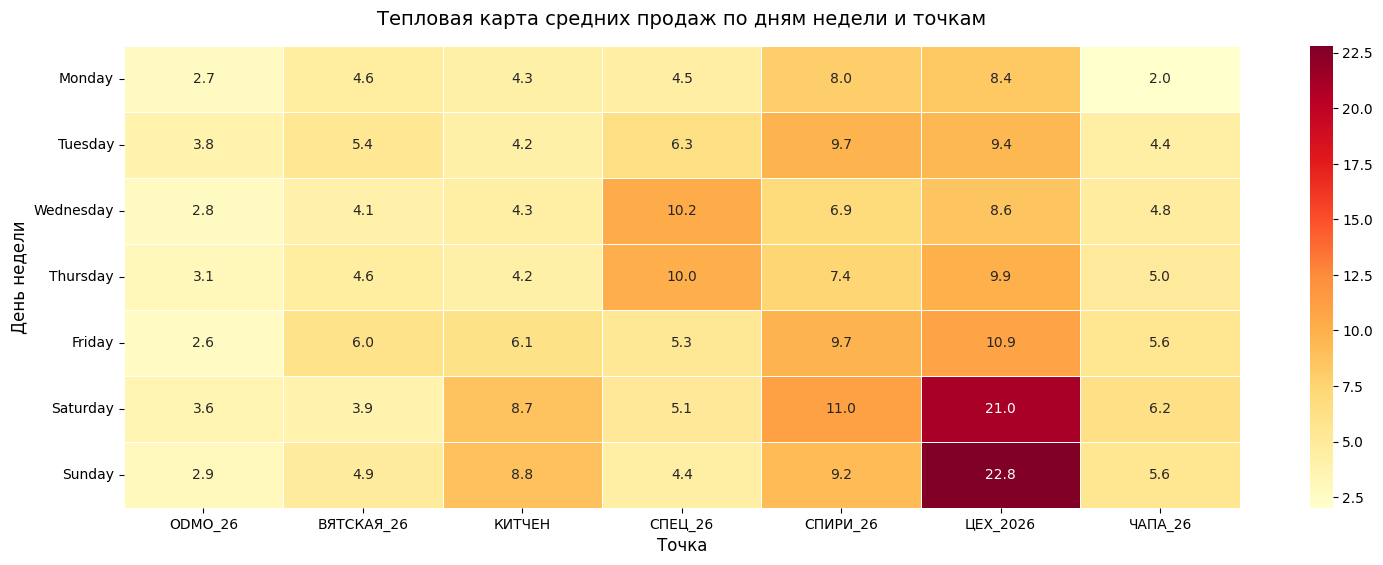

In [68]:
plt.figure(figsize=(18, 6))
sns.heatmap(weekly_pattern, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Тепловая карта средних продаж по дням недели и точкам', fontsize=14, pad=15)
plt.ylabel('День недели', fontsize=12)
plt.xlabel('Точка', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_9568\1973859364.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')


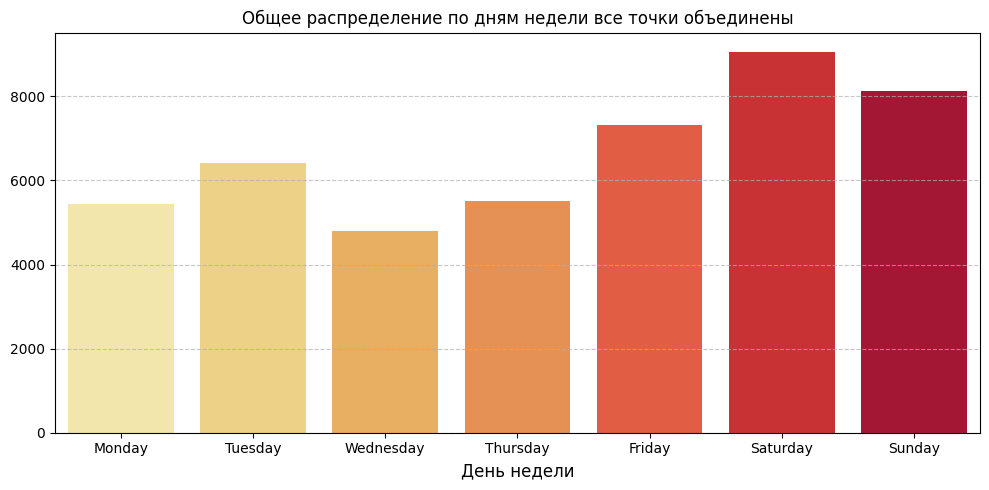

In [69]:
weekly_total = df_2026.groupby('Day_of_week')['Count'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

plt.figure(figsize=(10, 5))

sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')
plt.title('Общее распределение по дням недели все точки объединены', fontsize=12)
plt.xlabel('День недели', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

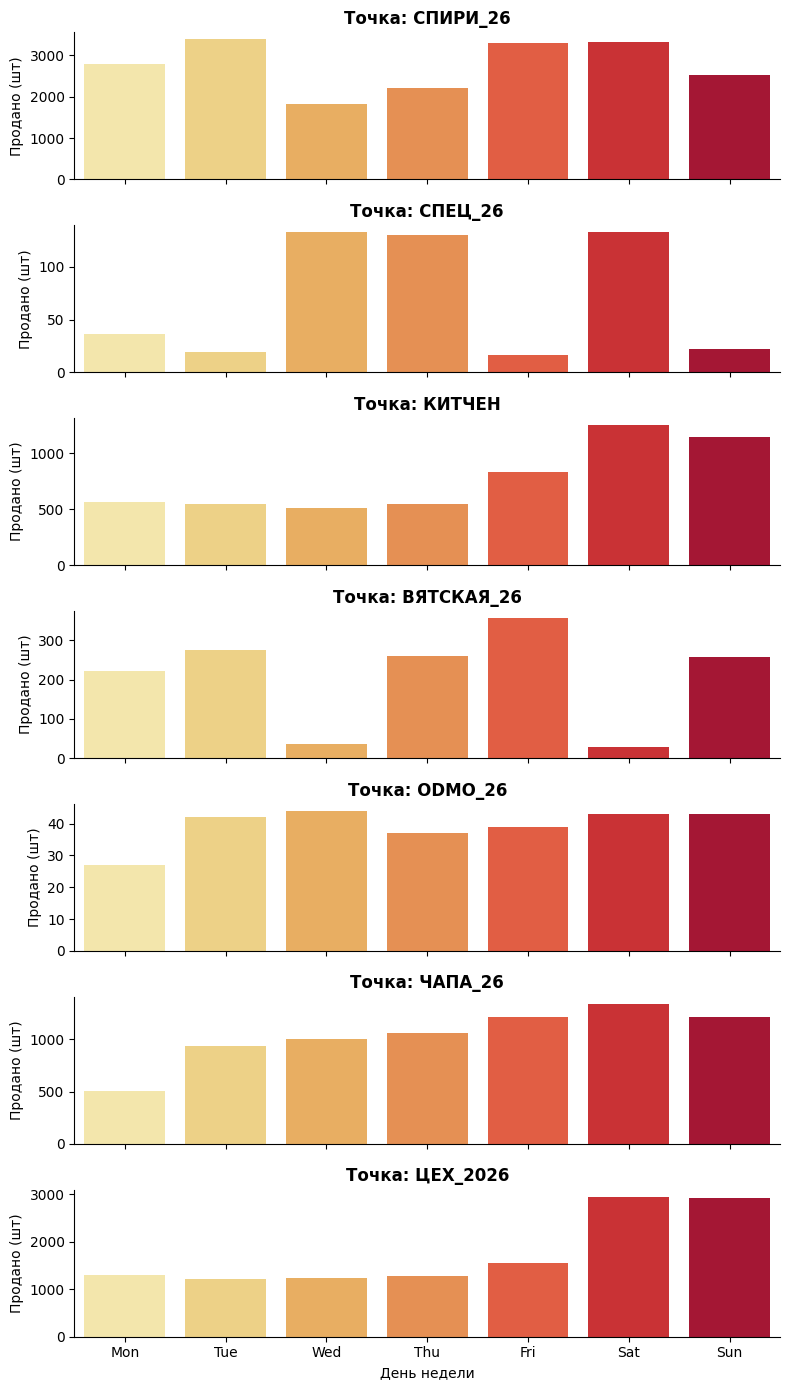

In [70]:
# 1. Считаем сумму продаж для каждого сочетания Точка + День недели
df_grouped = df_2026.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=False)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

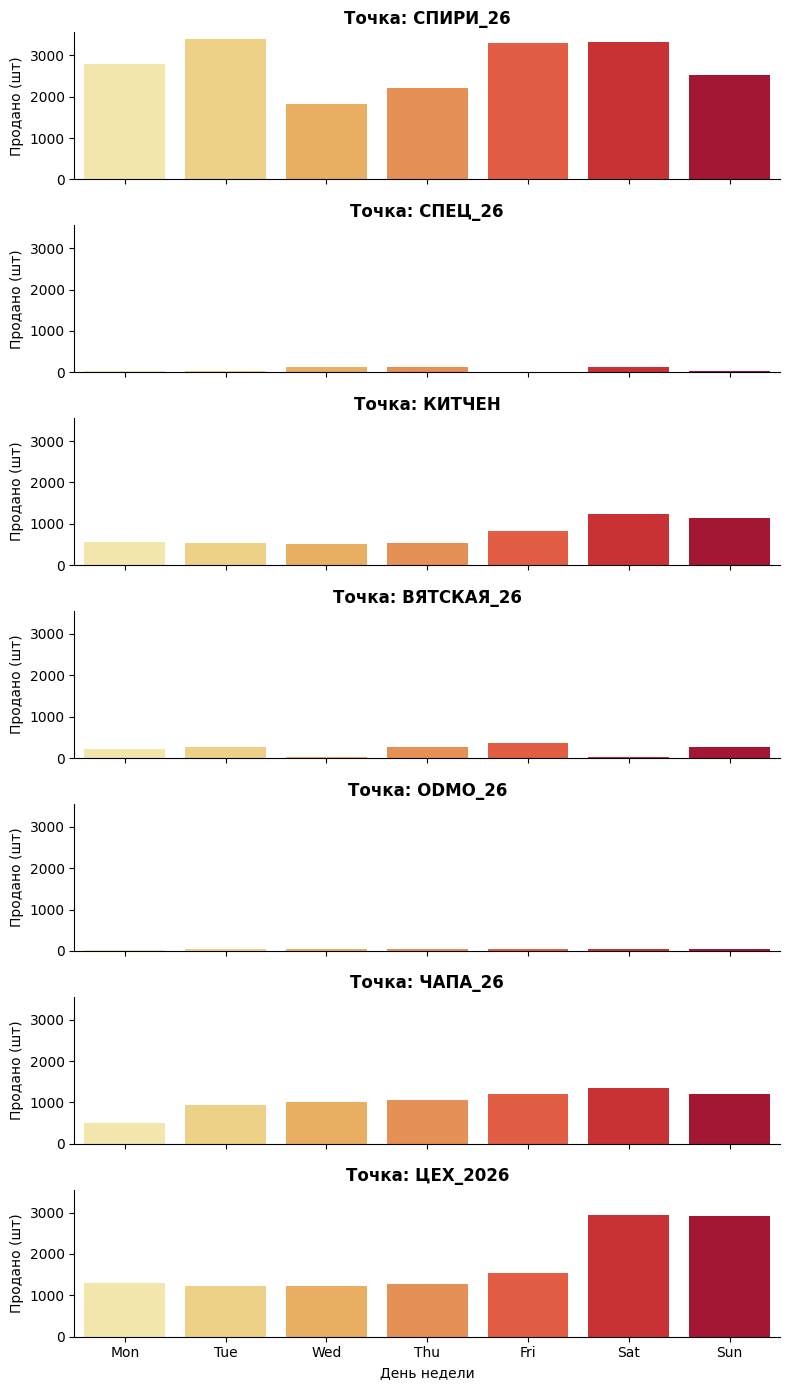

In [71]:

df_grouped = df_2026.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=True)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

Мы проверям насколько данные однородны.  
Допустим у нас есть какая то позиция, которая продаётся в один магазин, в большом колличестве (например печенье)
Если такие позиции имеются, без фильтрации данных сложнее интерпретировать графики связанные с общим колличеством всех товаров

In [72]:
product_totals = df_2026.groupby('Name')['Count'].sum().sort_values(ascending=False).to_frame()

total_volume = product_totals['Count'].sum()
product_totals['Share_%'] = (product_totals['Count'] / total_volume) * 100
product_totals['Cumulative_Share_%'] = product_totals['Share_%'].cumsum()
print('TOP 10 по общему объему')
print(product_totals.head(10).to_string())

max_item = product_totals['Count'].max()
median_item = product_totals['Count'].median()
anomaly_ratio = max_item / median_item if median_item > 0 else 0

print(f"Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в {anomaly_ratio:.1f})")

if anomaly_ratio > 50:
    print("КРАЙНЕ НЕОДНОРОДНА")
else:
    print("Структура данных однородна")

TOP 10 по общему объему
                     Count   Share_%  Cumulative_Share_%
Name                                                    
Бейгл 100           4009.0  8.591573            8.591573
Аманн               3533.0  7.571471           16.163045
Булка с маком       3317.0  7.108568           23.271613
Морнинг бан жасмин  2300.0  4.929064           28.200677
Круассан 75г        2224.0  4.766191           32.966868
Булка с кардамоном  1833.0  3.928250           36.895118
Паштель де ната     1767.0  3.786807           40.681925
Багет               1722.0  3.690369           44.372294
Булка с тхиной      1588.0  3.403197           47.775492
Булка с корицей     1464.0  3.137457           50.912948
Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в 12.4)
Структура данных однородна


In [73]:
categories_df = pd.read_csv('categories.csv')
categories_df

,Name,Category,Status
0,Аманн,Булки,Активный
1,Аманн Черный кунжут,Булки,Снят
2,Бабка Кардамон,Булки,Снят
3,Бабка Корица,Булки,Снят
4,Бабка корица и карамель,Булки,Активный
...,...,...,...
194,Горчица пф,Полуфабрикаты,пф
195,Квашеная капуста пф,Полуфабрикаты,пф
196,Ханни баттер тост,Десерты,Снят
197,Морнинг бан жасмин,Булки,Активный


In [74]:
df_2026 = pd.merge(df_2026, categories_df, on='Name', how='left')
df_2026

,Date,Name,Count,Point,Day_of_week,Category,Status
0,2026-06-01,Аманн,10.0,ЦЕХ_2026,Monday,Булки,Активный
1,2026-06-02,Аманн,10.0,ЦЕХ_2026,Tuesday,Булки,Активный
2,2026-06-03,Аманн,10.0,ЦЕХ_2026,Wednesday,Булки,Активный
3,2026-06-04,Аманн,12.0,ЦЕХ_2026,Thursday,Булки,Активный
4,2026-06-05,Аманн,20.0,ЦЕХ_2026,Friday,Булки,Активный
...,...,...,...,...,...,...,...
6218,2026-07-04,Фокачча 400х600,8.0,СПЕЦ_26,Saturday,Хлеб,пф
6219,2026-07-18,Фокачча 400х600,2.0,СПЕЦ_26,Saturday,Хлеб,пф
6220,2026-07-04,Фокачча GN 2/3,2.0,СПЕЦ_26,Saturday,Хлеб,Снят
6221,2026-07-09,Морнинг бан жасмин,5.0,СПЕЦ_26,Thursday,Булки,Активный


У некоторых данных есть опечатки в названиях !!!!хани баттер, морнинг бан жасмин

In [75]:
missing_categories = df_2026[df_2026['Category'].isna()]['Name'].unique()

if len(missing_categories) > 0:
    print(missing_categories)

['Хани баттер тост']


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_9568\1144295885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')


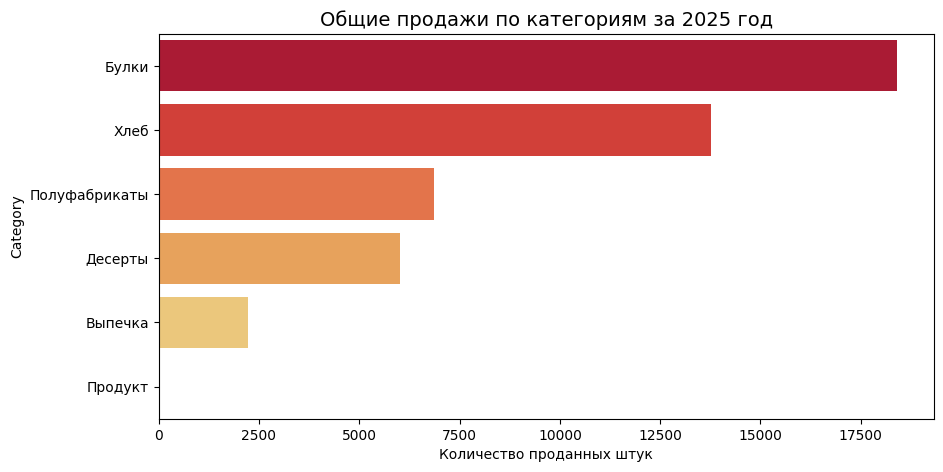

In [76]:
# Строим график объемов продаж по категориям товаров
plt.figure(figsize=(10, 5))
category_sales = df_2026.groupby('Category')['Count'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')
plt.title('Общие продажи по категориям за 2025 год', fontsize=14)
plt.xlabel('Количество проданных штук')
plt.show()


In [77]:
# 1. Считаем общие продажи каждого товара за 2025 год
product_sales = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()

# 2. Магия Pandas: делим продажи товара на сумму продаж ВСЕЙ его категории (через transform)
product_sales['Доля_в_категории_%'] = (
    product_sales['Count'] / product_sales.groupby('Category')['Count'].transform('sum')
) * 100

# Сортируем для красоты: сначала по категориям, а внутри них — от лидеров к аутсайдерам
product_sales = product_sales.sort_values(['Category', 'Доля_в_категории_%'], ascending=[True, False])

print("--- ТОП-3 ТОВАРА ВНУТРИ КАЖДОЙ КАТЕГОРИИ (НОРМИРОВАНО) ---")
print(product_sales.groupby('Category').head(3).to_string(index=False))


--- ТОП-3 ТОВАРА ВНУТРИ КАЖДОЙ КАТЕГОРИИ (НОРМИРОВАНО) ---
     Category                                   Name  Count  Доля_в_категории_%
        Булки                                  Аманн 3533.0           19.205262
        Булки                     Морнинг бан жасмин 2300.0           12.502718
        Булки                           Круассан 75г 2224.0           12.089585
      Выпечка Кекс шоколад с кремом вареная сгущенка 1213.0           54.565902
      Выпечка           Даниш франжипан грецкий орех  516.0           23.211876
      Выпечка                       Улитка с беконом  280.0           12.595592
      Десерты                        Паштель де ната 1767.0           29.376559
      Десерты             Печенье шоколадное с солью 1277.0           21.230258
      Десерты                      Печенье для собак 1020.0           16.957606
Полуфабрикаты                ПФ печенье шоколад-соль  975.0           14.208686
Полуфабрикаты                               ПФ Аманн  622.0  

<Figure size 1400x800 with 0 Axes>

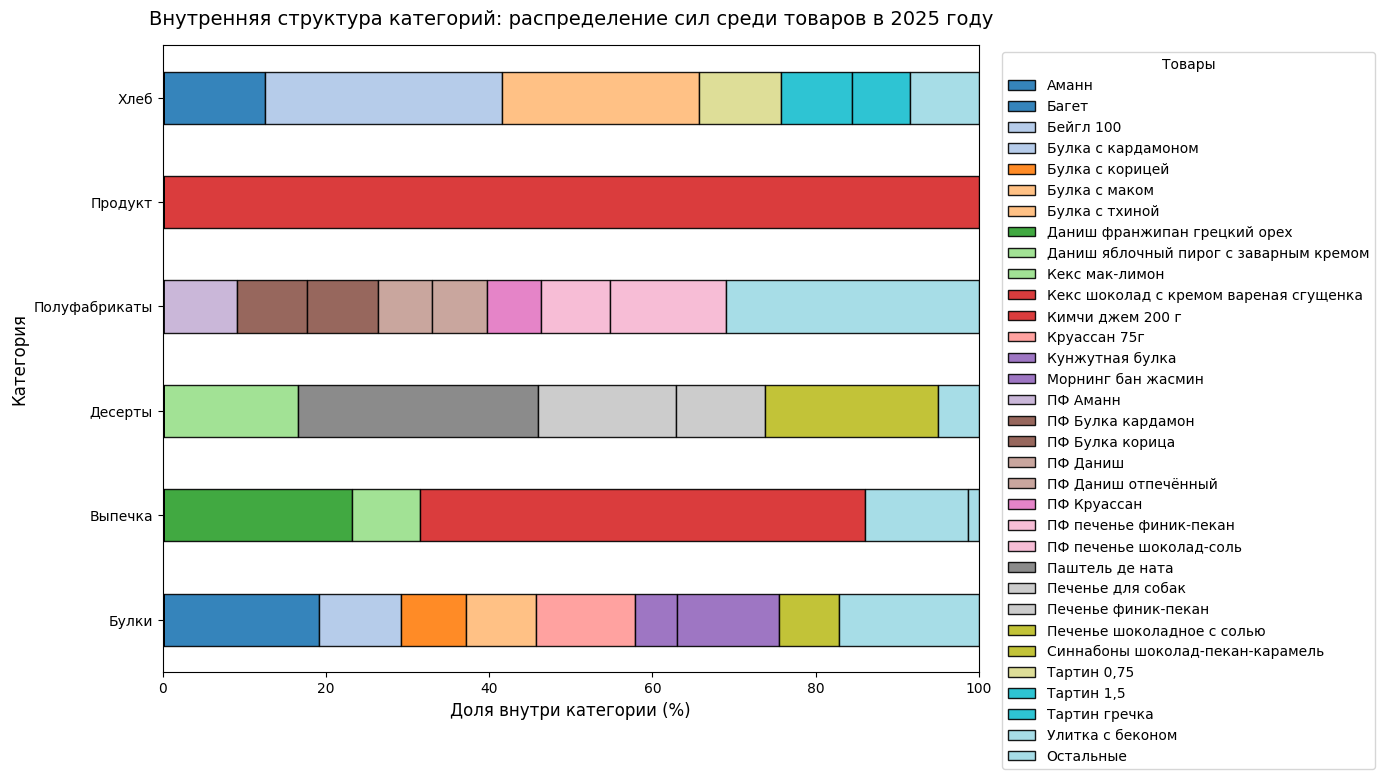

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем продажи и доли товаров внутри категорий
prod_structure = df_2026.groupby(['Category', 'Name'])['Count'].sum().reset_index()
prod_structure['Share_%'] = (prod_structure['Count'] / prod_structure.groupby('Category')['Count'].transform('sum')) * 100

# 2. Схлопываем мелкие товары (< 5% внутри категории) в группу "Остальные", чтобы не было каши
prod_structure.loc[prod_structure['Share_%'] < 5, 'Name'] = 'Остальные'
pivot_structure = prod_structure.groupby(['Category', 'Name'])['Share_%'].sum().unstack().fillna(0)

# Сортируем колонки так, чтобы "Остальные" были в самом конце (на графике — на правом краю)
if 'Остальные' in pivot_structure.columns:
    cols = [c for c in pivot_structure.columns if c != 'Остальные'] + ['Остальные']
    pivot_structure = pivot_structure[cols]

# 3. Строим горизонтальный 100% график
# Используем большую качественную палитру для множества товаров
plt.figure(figsize=(14, 8))
pivot_structure.plot(kind='barh', stacked=True, figsize=(14, 8), cmap='tab20', edgecolor='black', alpha=0.9)

# Настраиваем оформление
plt.title('Внутренняя структура категорий: распределение сил среди товаров в 2025 году', fontsize=14, pad=15)
plt.xlabel('Доля внутри категории (%)', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.xlim(0, 100)

# Выносим легенду вправо, чтобы она не перекрывала график
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Товары")
plt.tight_layout()
plt.show()
